In [58]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binned_statistic
from src.plotting import array_midpoints
from src.loading import (
    load_gpm_feature_stats,
    load_dyamond_feature_stats,
    load_imerg_feature_stats,
    load_dyamond_accum_test_feature_stats
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We load feature stats, from gSAM, over different accumulations

In [60]:
_EDGE_FRAC_MAX = 0.1
accum_features_dict = {
    'GPM': load_gpm_feature_stats(threshold=1, res='0p05'),
    'instant': load_dyamond_accum_test_feature_stats(accum='instant', edge_frac_max=_EDGE_FRAC_MAX),
    '15min': load_dyamond_accum_test_feature_stats(accum='15min', edge_frac_max=_EDGE_FRAC_MAX),
    '30min': load_dyamond_accum_test_feature_stats(accum='30min', edge_frac_max=_EDGE_FRAC_MAX),
}

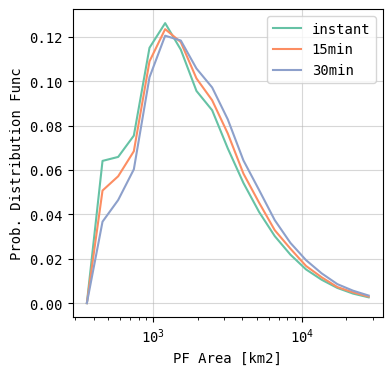

In [39]:
fig, ax = plt.subplots(figsize=(4,4))

# Plot PDF
for accum, df in accum_features_dict.items():
    area_bins = np.logspace(2.5, 4.5, 20)
    counts = binned_statistic(
        df['area_km2'],
        None,
        'count', 
        bins=area_bins
    ).statistic
    pdf = counts / counts.sum()
    ax.plot(
            array_midpoints(area_bins),
            pdf,
            label=accum,
        )
ax.set_xscale('log')
ax.legend()
ax.set_xlabel('PF Area [km2]')
ax.set_ylabel('Prob. Distribution Func')
ax.grid(alpha=0.5)

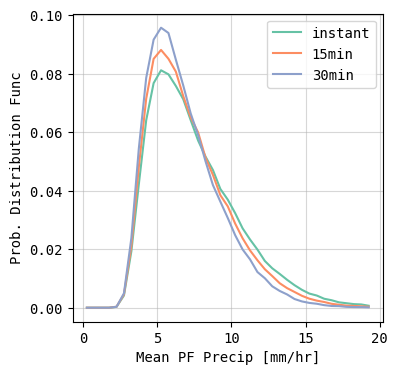

In [49]:
fig, ax = plt.subplots(figsize=(4,4))

# Plot PDF
for accum, df in accum_features_dict.items():
    bins = np.arange(0, 20, 0.5)
    counts = binned_statistic(
        df['mean_precip_mm_hr'],
        None,
        'count', 
        bins=bins
    ).statistic
    pdf = counts / counts.sum()
    ax.plot(
            array_midpoints(bins),
            pdf,
            label=accum,
        )
ax.legend()
ax.set_xlabel('Mean PF Precip [mm/hr]')
ax.set_ylabel('Prob. Distribution Func')
ax.grid(alpha=0.5)

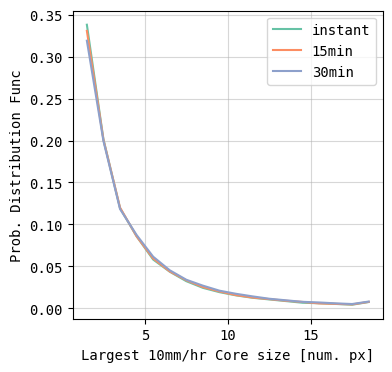

In [55]:
fig, ax = plt.subplots(figsize=(4,4))

# Plot PDF
for accum, df in accum_features_dict.items():

    bins = np.arange(1, 20, 1)
    counts = binned_statistic(
        df['largest_core_10mmhr_px'],
        None,
        'count', 
        bins=bins
    ).statistic
    pdf = counts / counts.sum()
    ax.plot(
            array_midpoints(bins),
            pdf,
            label=accum,
        )
ax.legend()
ax.set_xlabel('Largest 10mm/hr Core size [num. px]')
ax.set_ylabel('Prob. Distribution Func')
ax.grid(alpha=0.5)

In [40]:
df

source_file,feature_id,time,time_index,swath_id,px_in_swath,n_swaths,crosses_swath_boundary,size_px,area_km2,centroid_lat,centroid_lon,max_precip_mm_hr,mean_precip_mm_hr,total_precip_mm_hr_km2,px_ge_5mmhr,px_ge_10mmhr,n_cores_5mmhr,n_cores_10mmhr,largest_core_5mmhr_px,largest_core_10mmhr_px,cross_swath_extent_km,along_swath_extent_km,fits_in_swath,swath_edge_px,swath_edge_px_in_dominant,swath_edge_frac_in_dominant,perimeter_px,perimeter_px_no_grid_edge,domain_edge_px,touches_domain_edge
str,str,str,i64,i64,i64,i64,bool,i64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,f64,f64,bool,i64,i64,f64,i64,i64,i64,bool
"""/work/bb1153/b382284/dyamond/g…","""gSAM-4km_pracc_feb2020_30minac…","""2020-02-01T03:00:00.000000000""",0,131,18,1,false,18,2095.600718,-19.677696,40.327746,36.669319,9.726484,20382.17241,11,6,1,1,11,6,59.787015,40.310731,true,0,0,0.0,16,16,0,false
"""/work/bb1153/b382284/dyamond/g…","""gSAM-4km_pracc_feb2020_30minac…","""2020-02-01T03:00:00.000000000""",0,126,10,1,false,10,1163.843995,-19.729965,53.5,14.092711,5.72956,6668.826514,4,2,1,1,4,2,34.932349,29.553967,true,1,1,0.1,10,10,0,false
"""/work/bb1153/b382284/dyamond/g…","""gSAM-4km_pracc_feb2020_30minac…","""2020-02-01T03:00:00.000000000""",0,74,6,1,false,6,698.000232,-19.799984,179.35,11.624437,6.791626,4739.969076,4,1,1,1,4,1,24.854666,19.476284,true,0,0,0.0,6,6,0,false
"""/work/bb1153/b382284/dyamond/g…","""gSAM-4km_pracc_feb2020_30minac…","""2020-02-01T03:00:00.000000000""",0,72,22,1,false,22,2563.964628,-19.50884,-176.45439,32.952477,9.088869,23302.245259,10,8,2,2,6,4,46.368195,83.9626,true,0,0,0.0,21,21,0,false
"""/work/bb1153/b382284/dyamond/g…","""gSAM-4km_pracc_feb2020_30minac…","""2020-02-01T03:00:00.000000000""",0,68,16,1,false,16,1863.00388,-19.656114,-167.412495,24.083332,8.604683,16030.845413,8,5,1,1,8,5,38.952568,55.087715,true,1,1,0.0625,15,15,0,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""/work/bb1153/b382284/dyamond/g…","""gSAM-4km_pracc_feb2020_30minac…","""2020-02-29T21:00:00.000000000""",214,85,10,1,false,10,1173.014219,18.429967,169.499953,11.195426,3.627038,4254.482003,2,1,1,1,2,1,40.989813,43.651869,true,0,0,0.0,10,10,0,false
"""/work/bb1153/b382284/dyamond/g…","""gSAM-4km_pracc_feb2020_30minac…","""2020-02-29T21:00:00.000000000""",214,82,7,1,false,7,821.287556,18.392843,176.821421,12.008747,5.240197,4303.983455,3,1,1,1,3,1,30.233048,24.175585,true,0,0,0.0,7,7,0,false
"""/work/bb1153/b382284/dyamond/g…","""gSAM-4km_pracc_feb2020_30minac…","""2020-02-29T21:00:00.000000000""",214,34,14,1,false,14,1639.821891,18.678341,-66.464321,24.695873,6.701244,10983.792959,7,3,3,1,4,3,38.952568,69.864698,true,0,0,0.0,14,14,0,false
